In [ ]:
# %%

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
import glob
import re
import pickle
import networkx as nx

from data_io import import_all_log, parse_path_string    

In [ ]:
contact_list

NameError: name 'contact_list' is not defined

In [ ]:
# %%

for pth in pathlist:
    
    # find csv file
    data_path = None
    for file in Path(pth).rglob('*.csv'):
        if str(file.stem).endswith('lastFrame'):
            continue
        
        data_path = file
        break
    
    log_string = ''
    
    file_id,surfix,num_rods,AR,datetime_string = parse_path_string(data_path)
    time_line, node_list, contact_list = import_all_log(data_path,max_rows=100000)
    
    time_line = np.array(time_line)
    time_line = time_line[time_line <= 10]
    node_list = node_list[:len(time_line)]
    contact_list = contact_list[:len(time_line)]
    
    print(f'Size of time_line: {len(time_line)}')
    print(f'Number of rods: {num_rods}')
    
    log_string = log_string + f'Number of rods: {num_rods}\n'
    log_string = log_string + f'Number of time points: {len(time_line)}\n'
    
    output_path = f'{output_root}/{protocol_id}/{file_id}_{surfix}'
    if not os.path.exists(output_path):
        os.makedirs(output_path)
        start_point = 0
    else:
        start_point = len(glob.glob(f'{output_path}/*.png'))        
        
    nodes_in_matrix = node_list[0].reshape((-1,30))
    packing_center = np.mean(np.mean(nodes_in_matrix.reshape((-1,10,3)),axis=1),axis=0)
    
    
    fig,ax=plt.subplots(subplot_kw={'projection':'3d'})
    locked_nodes = []
    for rr in nodes_in_matrix.reshape((-1,10,3)):
        I = np.linalg.norm(rr - packing_center,axis=1) < 0.1
        locked_nodes.append(rr[I,:])
    
    for i in range(start_point,len(node_list),1):
        nodes_in_matrix = node_list[i].reshape((-1,30))
        
        contact_list

NameError: name 'pathlist' is not defined

In [ ]:
# %%

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
import glob
import re
import pickle
import networkx as nx

from data_io import import_all_log, parse_path_string    

In [ ]:
# %%

output_root = '/Users/yeonsu/Dropbox (Harvard University)/Data/PrunedData/rod-sim-pnas-revision'

# Jostle
protocol_id = 'HangEECarrotCake5'

pathlist = []
pathlist.append('/Users/yeonsu/Dropbox (Harvard University)/Data/from-cluster/HangEECarrotCake5/20240604-0050_RUN_HangEECarrotCake5_N125_AR25')
pathlist.append('/Users/yeonsu/Dropbox (Harvard University)/Data/from-cluster/HangEECarrotCake5/20240604-0050_RUN_HangEECarrotCake5_N500_AR100')
pathlist.append('/Users/yeonsu/Dropbox (Harvard University)/Data/from-cluster/HangEECarrotCake5/20240604-0110_RUN_HangEECarrotCake5_N250_AR50')
pathlist.append('/Users/yeonsu/Dropbox (Harvard University)/Data/from-cluster/HangEECarrotCake5/20240604-0110_RUN_HangEECarrotCake5_N375_AR75')
pathlist.append('/Users/yeonsu/Dropbox (Harvard University)/Data/from-cluster/HangEECarrotCake5/20240604-0110_RUN_HangEECarrotCake5_N625_AR125')
pathlist.append('/Users/yeonsu/Dropbox (Harvard University)/Data/from-cluster/HangEECarrotCake5/20240604-0110_RUN_HangEECarrotCake5_N1000_AR200')
pathlist.append('/Users/yeonsu/Dropbox (Harvard University)/Data/from-cluster/HangEECarrotCake5/20240604-0110_RUN_HangEECarrotCake5_N1500_AR300')

# for pth in pathlist:    
#     # find csv file
#     data_path = None
#     for file in Path(pth).rglob('*.csv'):
#         if str(file.stem).endswith('lastFrame'):
#             continue
        
#         data_path = file
#         break
    
#     log_string = ''
    
#     file_id,surfix,num_rods,AR,datetime_string = parse_path_string(data_path)
#     time_line, node_list, contact_list = import_all_log(data_path,max_rows=100000)
    
#     time_line = np.array(time_line)
#     time_line = time_line[time_line <= 10]
#     node_list = node_list[:len(time_line)]
#     contact_list = contact_list[:len(time_line)]
    
#     print(f'Size of time_line: {len(time_line)}')
#     print(f'Number of rods: {num_rods}')
    
#     log_string = log_string + f'Number of rods: {num_rods}\n'
#     log_string = log_string + f'Number of time points: {len(time_line)}\n'
    
#     output_path = f'{output_root}/{protocol_id}/{file_id}_{surfix}'
#     if not os.path.exists(output_path):
#         os.makedirs(output_path)
#         start_point = 0
#     else:
#         start_point = len(glob.glob(f'{output_path}/*.png'))        
        
#     nodes_in_matrix = node_list[0].reshape((-1,30))
#     packing_center = np.mean(np.mean(nodes_in_matrix.reshape((-1,10,3)),axis=1),axis=0)
    
    
#     fig,ax=plt.subplots(subplot_kw={'projection':'3d'})
#     locked_nodes = []
#     for rr in nodes_in_matrix.reshape((-1,10,3)):
#         I = np.linalg.norm(rr - packing_center,axis=1) < 0.1
#         # ax.plot(rr[I,0],rr[I,1],rr[I,2],'k-')
#         locked_nodes.append(rr[I,:])
        
#     print(f'Number of locked nodes: {len(locked_nodes)}')
    
#     for i in range(start_point,len(node_list),1):
#         nodes_in_matrix = node_list[i].reshape((-1,30))
#         for node in nodes_in_matrix:
#             rr = node.reshape((-1,3))
#             ax.plot(rr[:,0],rr[:,1],rr[:,2],alpha=0.1)
            
#         for rr in locked_nodes:
#             ax.plot(rr[:,0],rr[:,1],rr[:,2],'k-',linewidth=2)
            
#         ax.set_xlim(-2,2)
#         ax.set_ylim(-2,2)
#         ax.set_zlim(-2,2)
#         ax.view_init(elev=0,azim=0)
#         ax.text(1,1,1,f'time: {time_line[i]}')
#         plt.tight_layout(pad=0)
        
#         plt.savefig(f'{output_path}/frames_{i:04d}.png', dpi=300, bbox_inches='tight', pad_inches=0)
#         ax.clear()
        
#     with open(f'{output_path}/log.txt','w') as f:
#         f.write(log_string)

Size of time_line: 334
Number of rods: 125
Size of time_line: 334
Number of rods: 500
Size of time_line: 334
Number of rods: 250
Size of time_line: 334
Number of rods: 375
Size of time_line: 334
Number of rods: 625
Size of time_line: 334
Number of rods: 1000
Size of time_line: 334
Number of rods: 1500


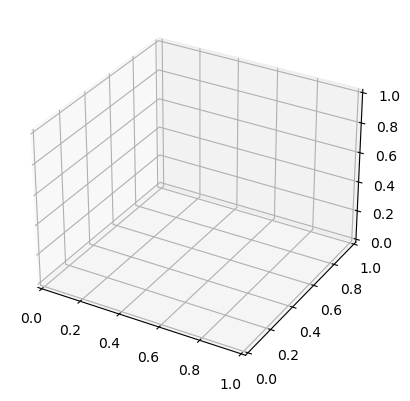

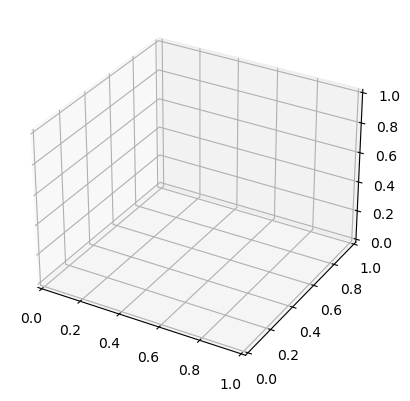

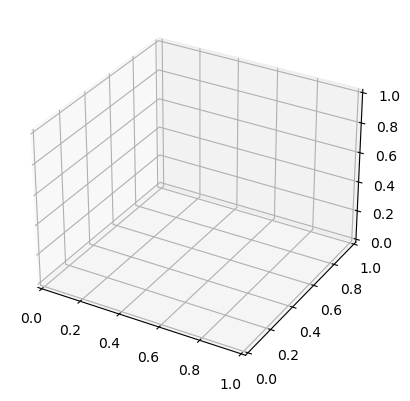

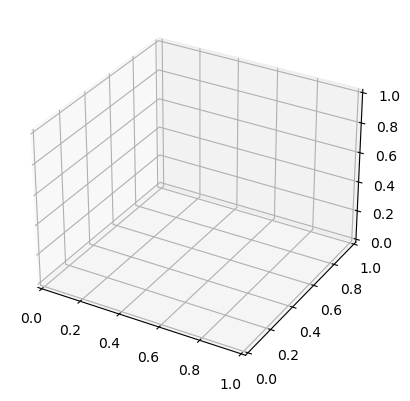

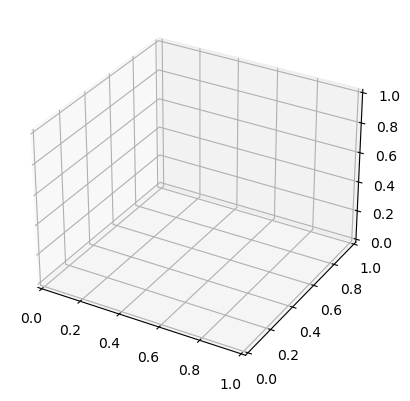

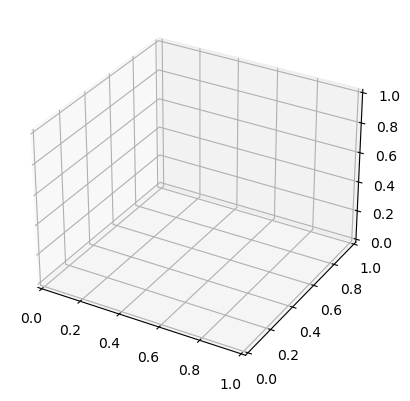

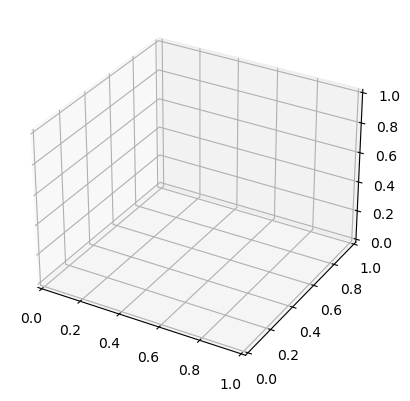

In [ ]:
# %%

for pth in pathlist:
    
    # find csv file
    data_path = None
    for file in Path(pth).rglob('*.csv'):
        if str(file.stem).endswith('lastFrame'):
            continue
        
        data_path = file
        break
    
    log_string = ''
    
    file_id,surfix,num_rods,AR,datetime_string = parse_path_string(data_path)
    time_line, node_list, contact_list = import_all_log(data_path,max_rows=100000)
    
    time_line = np.array(time_line)
    time_line = time_line[time_line <= 10]
    node_list = node_list[:len(time_line)]
    contact_list = contact_list[:len(time_line)]
    
    print(f'Size of time_line: {len(time_line)}')
    print(f'Number of rods: {num_rods}')
    
    log_string = log_string + f'Number of rods: {num_rods}\n'
    log_string = log_string + f'Number of time points: {len(time_line)}\n'
    
    output_path = f'{output_root}/{protocol_id}/{file_id}_{surfix}'
    if not os.path.exists(output_path):
        os.makedirs(output_path)
        start_point = 0
    else:
        start_point = len(glob.glob(f'{output_path}/*.png'))        
        
    nodes_in_matrix = node_list[0].reshape((-1,30))
    packing_center = np.mean(np.mean(nodes_in_matrix.reshape((-1,10,3)),axis=1),axis=0)
    
    
    fig,ax=plt.subplots(subplot_kw={'projection':'3d'})
    locked_nodes = []
    for rr in nodes_in_matrix.reshape((-1,10,3)):
        I = np.linalg.norm(rr - packing_center,axis=1) < 0.1
        locked_nodes.append(rr[I,:])
    
    for i in range(start_point,len(node_list),1):
        nodes_in_matrix = node_list[i].reshape((-1,30))
        
        contact_list

In [ ]:
contact_list

[array([], dtype=float64),
 array([ 5.      ,  2.      ,  6.      , ...,  0.038901, -0.068221,
        -0.085786]),
 array([ 3.00e+00,  4.00e+00,  4.00e+00, ...,  9.12e-04, -4.62e-04,
        -7.78e-04]),
 array([ 3.00e+00,  2.00e+00,  4.00e+00, ...,  4.10e-05, -3.30e-05,
        -1.15e-04]),
 array([7.000e+00, 5.000e+00, 8.000e+00, ..., 1.424e-03, 1.030e-04,
        2.010e-04]),
 array([ 0.,  2.,  1., ...,  0., -0., -0.]),
 array([ 6.      ,  5.      ,  7.      , ...,  0.028697, -0.010272,
        -0.015213]),
 array([ 2.0e+00,  5.0e+00,  3.0e+00, ..., -6.5e-05,  2.4e-05, -7.2e-05]),
 array([ 6.000e+00,  1.000e+00,  7.000e+00, ..., -4.160e-04,  1.188e-03,
        -3.170e-04]),
 array([ 6.00000e+00,  3.00000e+00,  7.00000e+00, ..., -6.60310e-02,
         5.46800e-03, -1.04352e-01]),
 array([ 5.,  4.,  6., ..., -0., -0.,  0.]),
 array([ 4.      ,  3.      ,  5.      , ...,  0.025995,  0.014389,
        -0.046085]),
 array([ 5.      ,  4.      ,  6.      , ..., -0.115832,  0.174471,
    

In [ ]:
contact_list

[array([], dtype=float64),
 array([ 5.      ,  2.      ,  6.      , ...,  0.038901, -0.068221,
        -0.085786]),
 array([ 3.00e+00,  4.00e+00,  4.00e+00, ...,  9.12e-04, -4.62e-04,
        -7.78e-04]),
 array([ 3.00e+00,  2.00e+00,  4.00e+00, ...,  4.10e-05, -3.30e-05,
        -1.15e-04]),
 array([7.000e+00, 5.000e+00, 8.000e+00, ..., 1.424e-03, 1.030e-04,
        2.010e-04]),
 array([ 0.,  2.,  1., ...,  0., -0., -0.]),
 array([ 6.      ,  5.      ,  7.      , ...,  0.028697, -0.010272,
        -0.015213]),
 array([ 2.0e+00,  5.0e+00,  3.0e+00, ..., -6.5e-05,  2.4e-05, -7.2e-05]),
 array([ 6.000e+00,  1.000e+00,  7.000e+00, ..., -4.160e-04,  1.188e-03,
        -3.170e-04]),
 array([ 6.00000e+00,  3.00000e+00,  7.00000e+00, ..., -6.60310e-02,
         5.46800e-03, -1.04352e-01]),
 array([ 5.,  4.,  6., ..., -0., -0.,  0.]),
 array([ 4.      ,  3.      ,  5.      , ...,  0.025995,  0.014389,
        -0.046085]),
 array([ 5.      ,  4.      ,  6.      , ..., -0.115832,  0.174471,
    

In [ ]:
contact_list[0:1]

[array([], dtype=float64)]

In [ ]:
contact_list[:,0:1]

TypeError: list indices must be integers or slices, not tuple

In [ ]:
contact_list

[array([], dtype=float64),
 array([ 5.      ,  2.      ,  6.      , ...,  0.038901, -0.068221,
        -0.085786]),
 array([ 3.00e+00,  4.00e+00,  4.00e+00, ...,  9.12e-04, -4.62e-04,
        -7.78e-04]),
 array([ 3.00e+00,  2.00e+00,  4.00e+00, ...,  4.10e-05, -3.30e-05,
        -1.15e-04]),
 array([7.000e+00, 5.000e+00, 8.000e+00, ..., 1.424e-03, 1.030e-04,
        2.010e-04]),
 array([ 0.,  2.,  1., ...,  0., -0., -0.]),
 array([ 6.      ,  5.      ,  7.      , ...,  0.028697, -0.010272,
        -0.015213]),
 array([ 2.0e+00,  5.0e+00,  3.0e+00, ..., -6.5e-05,  2.4e-05, -7.2e-05]),
 array([ 6.000e+00,  1.000e+00,  7.000e+00, ..., -4.160e-04,  1.188e-03,
        -3.170e-04]),
 array([ 6.00000e+00,  3.00000e+00,  7.00000e+00, ..., -6.60310e-02,
         5.46800e-03, -1.04352e-01]),
 array([ 5.,  4.,  6., ..., -0., -0.,  0.]),
 array([ 4.      ,  3.      ,  5.      , ...,  0.025995,  0.014389,
        -0.046085]),
 array([ 5.      ,  4.      ,  6.      , ..., -0.115832,  0.174471,
    

In [ ]:
curr_contact_list = contact_list[i]

NameError: name 'i' is not defined

In [ ]:
curr_contact_list

NameError: name 'curr_contact_list' is not defined

In [ ]:
for i in range(start_point,len(node_list),1):
    nodes_in_matrix = node_list[i].reshape((-1,30))
    
    curr_contact_list = contact_list[i]

In [ ]:
curr_contact_list

NameError: name 'curr_contact_list' is not defined

In [ ]:
curr_contact_list = contact_list[i]

NameError: name 'i' is not defined

In [ ]:
start_point

334

In [ ]:
start_point = 0

In [ ]:
start_point = 0

In [ ]:
for i in range(start_point,len(node_list),1):
    nodes_in_matrix = node_list[i].reshape((-1,30))
    
    curr_contact_list = contact_list[i]

In [ ]:
curr_contact_list

array([ 5.000e+00,  4.000e+00,  6.000e+00, ...,  4.896e-03, -1.649e-03,
        7.750e-03])

In [ ]:
curr_contact_list = contact_list[i]
curr_contact_list = curr_contact_list.reshape(-1,18)

In [ ]:
curr_contact_list

array([[ 5.00000e+00,  4.00000e+00,  6.00000e+00, ...,  1.95174e-01,
        -1.05831e-01, -9.60770e-02],
       [ 5.00000e+00,  7.00000e+00,  6.00000e+00, ..., -0.00000e+00,
         0.00000e+00,  0.00000e+00],
       [ 4.00000e+00,  4.00000e+00,  5.00000e+00, ...,  2.25688e-01,
         3.41335e-01, -2.23199e-01],
       ...,
       [ 2.00000e+00,  4.00000e+00,  3.00000e+00, ...,  1.44910e-02,
        -6.71650e-02, -3.63990e-02],
       [ 8.00000e+00,  1.00000e+00,  9.00000e+00, ..., -9.09300e-03,
        -8.46400e-03,  3.69800e-02],
       [ 5.00000e+00,  6.00000e+00,  6.00000e+00, ...,  4.89600e-03,
        -1.64900e-03,  7.75000e-03]])

In [ ]:
curr_contact_list[:,4:5]

array([[820.],
       [820.],
       [820.],
       ...,
       [171.],
       [172.],
       [171.]])

In [ ]:
curr_contact_list[:,4:6]

array([[ 820.,  833.],
       [ 820., 1057.],
       [ 820., 1070.],
       ...,
       [ 171.,  583.],
       [ 172.,  827.],
       [ 171., 1146.]])

In [ ]:
curr_contact_list[500:600,4:6]

array([[ 850., 1458.],
       [ 851., 1032.],
       [ 851., 1080.],
       [ 851., 1140.],
       [ 851., 1210.],
       [ 852.,  896.],
       [ 852., 1003.],
       [ 852., 1178.],
       [ 852., 1216.],
       [ 853., 1021.],
       [ 853., 1022.],
       [ 853., 1165.],
       [ 749., 1319.],
       [ 708.,  747.],
       [ 708.,  895.],
       [1133., 1434.],
       [1133., 1460.],
       [1134., 1290.],
       [1135., 1297.],
       [1135., 1323.],
       [1135., 1476.],
       [1136., 1146.],
       [1136., 1289.],
       [ 665.,  945.],
       [ 665., 1191.],
       [ 665., 1270.],
       [ 684.,  760.],
       [ 684.,  861.],
       [ 684.,  999.],
       [ 684., 1024.],
       [ 491., 1302.],
       [ 491., 1336.],
       [ 491., 1428.],
       [ 491., 1439.],
       [ 492.,  562.],
       [ 492.,  670.],
       [ 562.,  860.],
       [ 562.,  916.],
       [ 562., 1109.],
       [ 562., 1295.],
       [ 563.,  573.],
       [ 563.,  727.],
       [ 563.,  875.],
       [ 56

In [ ]:
curr_contact_list[:,4:6]

array([[ 820.,  833.],
       [ 820., 1057.],
       [ 820., 1070.],
       ...,
       [ 171.,  583.],
       [ 172.,  827.],
       [ 171., 1146.]])

In [ ]:
graph = nx.Graph()
graph.add_nodes_from(range(num_rods))
graph.add_edges_from(curr_contact_list[:,4:6])

In [ ]:
list(nx.connected_components(graph))

[{0,
  1.0,
  2.0,
  3.0,
  4.0,
  5.0,
  6.0,
  7.0,
  8.0,
  9.0,
  10.0,
  11.0,
  12.0,
  13.0,
  14.0,
  15.0,
  16.0,
  17.0,
  18.0,
  19.0,
  20.0,
  21.0,
  22.0,
  23.0,
  24.0,
  25.0,
  26.0,
  27.0,
  28.0,
  29.0,
  30.0,
  31.0,
  32.0,
  33.0,
  34.0,
  35.0,
  36.0,
  37.0,
  38.0,
  39.0,
  40.0,
  41.0,
  42.0,
  43.0,
  44.0,
  45.0,
  46.0,
  47.0,
  48.0,
  49.0,
  50.0,
  51.0,
  52.0,
  53.0,
  54.0,
  55.0,
  56.0,
  57.0,
  58.0,
  59.0,
  60.0,
  61.0,
  62.0,
  63.0,
  64.0,
  65.0,
  66.0,
  67.0,
  68.0,
  69.0,
  70.0,
  71.0,
  72.0,
  73.0,
  74.0,
  75.0,
  76.0,
  77.0,
  78.0,
  79.0,
  80.0,
  81.0,
  82.0,
  83.0,
  84.0,
  85.0,
  86.0,
  87.0,
  88.0,
  89.0,
  90.0,
  91.0,
  92.0,
  93.0,
  94.0,
  95.0,
  96.0,
  97.0,
  98.0,
  99.0,
  100.0,
  101.0,
  102.0,
  103.0,
  104.0,
  105.0,
  106.0,
  107.0,
  108.0,
  109.0,
  110.0,
  111.0,
  112.0,
  113.0,
  114.0,
  115.0,
  116.0,
  117.0,
  118.0,
  119.0,
  120.0,
  121.0,
  122.0,
  123

In [ ]:
conn_comp = list(nx.connected_components(graph))

In [ ]:
[len(cc) for cc in conn_comp]

[1484, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1]

In [ ]:
cl_size = [len(cc) for cc in conn_comp]
max(cl_size)

1484

In [ ]:
max(cl_size)

1484

Size of time_line: 334
Number of rods: 125


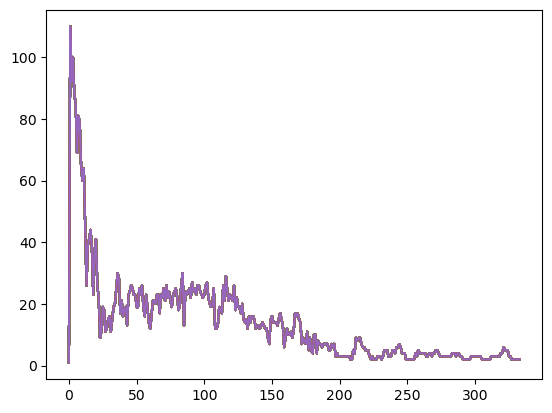

In [ ]:
# %%

for pth in pathlist:
    
    # find csv file
    data_path = None
    for file in Path(pth).rglob('*.csv'):
        if str(file.stem).endswith('lastFrame'):
            continue
        
        data_path = file
        break
    
    log_string = ''
    
    file_id,surfix,num_rods,AR,datetime_string = parse_path_string(data_path)
    time_line, node_list, contact_list = import_all_log(data_path,max_rows=100000)
    
    time_line = np.array(time_line)
    time_line = time_line[time_line <= 10]
    node_list = node_list[:len(time_line)]
    contact_list = contact_list[:len(time_line)]
    
    print(f'Size of time_line: {len(time_line)}')
    print(f'Number of rods: {num_rods}')
    
    log_string = log_string + f'Number of rods: {num_rods}\n'
    log_string = log_string + f'Number of time points: {len(time_line)}\n'
    
    output_path = f'{output_root}/{protocol_id}/{file_id}_{surfix}'
    if not os.path.exists(output_path):
        os.makedirs(output_path)
        start_point = 0
    else:
        start_point = len(glob.glob(f'{output_path}/*.png'))        
    start_point = 0
    nodes_in_matrix = node_list[0].reshape((-1,30))
    packing_center = np.mean(np.mean(nodes_in_matrix.reshape((-1,10,3)),axis=1),axis=0)
    
    locked_nodes = []
    for rr in nodes_in_matrix.reshape((-1,10,3)):
        I = np.linalg.norm(rr - packing_center,axis=1) < 0.1
        locked_nodes.append(rr[I,:])
    
    cluster_size = np.zeros((len(node_list),num_rods),dtype=int)
    for i in range(0,len(node_list),1):
        nodes_in_matrix = node_list[i].reshape((-1,30))
        
        curr_contact_list = contact_list[i]
        curr_contact_list = curr_contact_list.reshape(-1,18)
        
        graph = nx.Graph()
        graph.add_nodes_from(range(num_rods))
        graph.add_edges_from(curr_contact_list[:,4:6])
        conn_comp = list(nx.connected_components(graph))        
        cl_size = [len(cc) for cc in conn_comp]        
        cluster_size[i] = max(cl_size)
        
    plt.plot(cluster_size)
    break

# at edges between (idx1, idx3) and (idx2, idx4)
# (4 * idx1 + e1, contact_gradient[e1], idx5);
# (4 * idx3 + e1, contact_gradient[e1 + 3], idx5);
# (4 * idx2 + e1, contact_gradient[e1 + 6], idx6);
# (4 * idx4 + e1, contact_gradient[e1 + 9], idx6);

Size of time_line: 334
Number of rods: 125


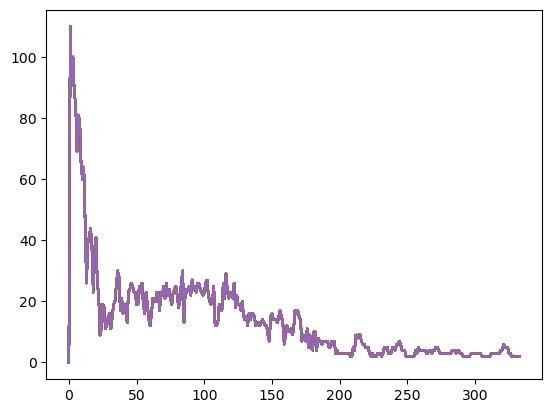

In [ ]:
# %%

for pth in pathlist:
    
    # find csv file
    data_path = None
    for file in Path(pth).rglob('*.csv'):
        if str(file.stem).endswith('lastFrame'):
            continue
        
        data_path = file
        break
    
    log_string = ''
    
    file_id,surfix,num_rods,AR,datetime_string = parse_path_string(data_path)
    time_line, node_list, contact_list = import_all_log(data_path,max_rows=100000)
    
    time_line = np.array(time_line)
    time_line = time_line[time_line <= 10]
    node_list = node_list[:len(time_line)]
    contact_list = contact_list[:len(time_line)]
    
    print(f'Size of time_line: {len(time_line)}')
    print(f'Number of rods: {num_rods}')
    
    log_string = log_string + f'Number of rods: {num_rods}\n'
    log_string = log_string + f'Number of time points: {len(time_line)}\n'
    
    output_path = f'{output_root}/{protocol_id}/{file_id}_{surfix}'
    if not os.path.exists(output_path):
        os.makedirs(output_path)
        start_point = 0
    else:
        start_point = len(glob.glob(f'{output_path}/*.png'))        
    start_point = 0
    nodes_in_matrix = node_list[0].reshape((-1,30))
    packing_center = np.mean(np.mean(nodes_in_matrix.reshape((-1,10,3)),axis=1),axis=0)
    
    locked_nodes = []
    for rr in nodes_in_matrix.reshape((-1,10,3)):
        I = np.linalg.norm(rr - packing_center,axis=1) < 0.1
        locked_nodes.append(rr[I,:])
    
    cluster_size = np.zeros((len(node_list),num_rods),dtype=int)
    for i in range(1,len(node_list),1):
        nodes_in_matrix = node_list[i].reshape((-1,30))
        
        curr_contact_list = contact_list[i]
        curr_contact_list = curr_contact_list.reshape(-1,18)
        
        graph = nx.Graph()
        graph.add_nodes_from(range(num_rods))
        graph.add_edges_from(curr_contact_list[:,4:6])
        conn_comp = list(nx.connected_components(graph))        
        cl_size = [len(cc) for cc in conn_comp]        
        cluster_size[i] = max(cl_size)
        
    plt.plot(cluster_size)
    break

# at edges between (idx1, idx3) and (idx2, idx4)
# (4 * idx1 + e1, contact_gradient[e1], idx5);
# (4 * idx3 + e1, contact_gradient[e1 + 3], idx5);
# (4 * idx2 + e1, contact_gradient[e1 + 6], idx6);
# (4 * idx4 + e1, contact_gradient[e1 + 9], idx6);

Size of time_line: 334
Number of rods: 125


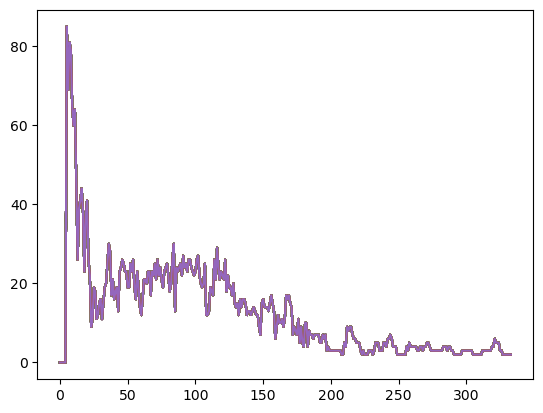

In [ ]:
# %%

for pth in pathlist:
    
    # find csv file
    data_path = None
    for file in Path(pth).rglob('*.csv'):
        if str(file.stem).endswith('lastFrame'):
            continue
        
        data_path = file
        break
    
    log_string = ''
    
    file_id,surfix,num_rods,AR,datetime_string = parse_path_string(data_path)
    time_line, node_list, contact_list = import_all_log(data_path,max_rows=100000)
    
    time_line = np.array(time_line)
    time_line = time_line[time_line <= 10]
    node_list = node_list[:len(time_line)]
    contact_list = contact_list[:len(time_line)]
    
    print(f'Size of time_line: {len(time_line)}')
    print(f'Number of rods: {num_rods}')
    
    log_string = log_string + f'Number of rods: {num_rods}\n'
    log_string = log_string + f'Number of time points: {len(time_line)}\n'
    
    output_path = f'{output_root}/{protocol_id}/{file_id}_{surfix}'
    if not os.path.exists(output_path):
        os.makedirs(output_path)
        start_point = 0
    else:
        start_point = len(glob.glob(f'{output_path}/*.png'))        
    start_point = 0
    nodes_in_matrix = node_list[0].reshape((-1,30))
    packing_center = np.mean(np.mean(nodes_in_matrix.reshape((-1,10,3)),axis=1),axis=0)
    
    locked_nodes = []
    for rr in nodes_in_matrix.reshape((-1,10,3)):
        I = np.linalg.norm(rr - packing_center,axis=1) < 0.1
        locked_nodes.append(rr[I,:])
    
    cluster_size = np.zeros((len(node_list),num_rods),dtype=int)
    for i in range(5,len(node_list),1):
        nodes_in_matrix = node_list[i].reshape((-1,30))
        
        curr_contact_list = contact_list[i]
        curr_contact_list = curr_contact_list.reshape(-1,18)
        
        graph = nx.Graph()
        graph.add_nodes_from(range(num_rods))
        graph.add_edges_from(curr_contact_list[:,4:6])
        conn_comp = list(nx.connected_components(graph))        
        cl_size = [len(cc) for cc in conn_comp]        
        cluster_size[i] = max(cl_size)
        
    plt.plot(cluster_size)
    break

# at edges between (idx1, idx3) and (idx2, idx4)
# (4 * idx1 + e1, contact_gradient[e1], idx5);
# (4 * idx3 + e1, contact_gradient[e1 + 3], idx5);
# (4 * idx2 + e1, contact_gradient[e1 + 6], idx6);
# (4 * idx4 + e1, contact_gradient[e1 + 9], idx6);

Size of time_line: 334
Number of rods: 125


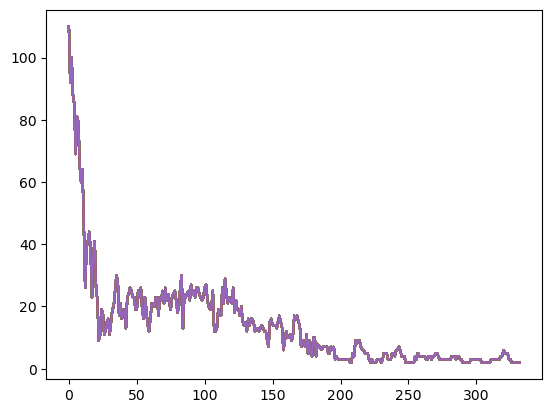

In [ ]:
# %%

for pth in pathlist:
    
    # find csv file
    data_path = None
    for file in Path(pth).rglob('*.csv'):
        if str(file.stem).endswith('lastFrame'):
            continue
        
        data_path = file
        break
    
    log_string = ''
    
    file_id,surfix,num_rods,AR,datetime_string = parse_path_string(data_path)
    time_line, node_list, contact_list = import_all_log(data_path,max_rows=100000)
    
    time_line = np.array(time_line)
    time_line = time_line[time_line <= 10]
    node_list = node_list[:len(time_line)]
    contact_list = contact_list[:len(time_line)]
    
    print(f'Size of time_line: {len(time_line)}')
    print(f'Number of rods: {num_rods}')
    
    log_string = log_string + f'Number of rods: {num_rods}\n'
    log_string = log_string + f'Number of time points: {len(time_line)}\n'
    
    output_path = f'{output_root}/{protocol_id}/{file_id}_{surfix}'
    if not os.path.exists(output_path):
        os.makedirs(output_path)
        start_point = 0
    else:
        start_point = len(glob.glob(f'{output_path}/*.png'))        
    start_point = 0
    nodes_in_matrix = node_list[0].reshape((-1,30))
    packing_center = np.mean(np.mean(nodes_in_matrix.reshape((-1,10,3)),axis=1),axis=0)
    
    locked_nodes = []
    for rr in nodes_in_matrix.reshape((-1,10,3)):
        I = np.linalg.norm(rr - packing_center,axis=1) < 0.1
        locked_nodes.append(rr[I,:])
    
    cluster_size = np.zeros((len(node_list)-1,num_rods),dtype=int)
    for i in range(1,len(node_list),1):
        nodes_in_matrix = node_list[i].reshape((-1,30))
        
        curr_contact_list = contact_list[i]
        curr_contact_list = curr_contact_list.reshape(-1,18)
        
        graph = nx.Graph()
        graph.add_nodes_from(range(num_rods))
        graph.add_edges_from(curr_contact_list[:,4:6])
        conn_comp = list(nx.connected_components(graph))        
        cl_size = [len(cc) for cc in conn_comp]        
        cluster_size[i-1] = max(cl_size)
        
    plt.plot(cluster_size)
    break

# at edges between (idx1, idx3) and (idx2, idx4)
# (4 * idx1 + e1, contact_gradient[e1], idx5);
# (4 * idx3 + e1, contact_gradient[e1 + 3], idx5);
# (4 * idx2 + e1, contact_gradient[e1 + 6], idx6);
# (4 * idx4 + e1, contact_gradient[e1 + 9], idx6);

Size of time_line: 334
Number of rods: 125
Size of time_line: 334
Number of rods: 500
Size of time_line: 334
Number of rods: 250
Size of time_line: 334
Number of rods: 375
Size of time_line: 334
Number of rods: 625
Size of time_line: 334
Number of rods: 1000
Size of time_line: 334
Number of rods: 1500


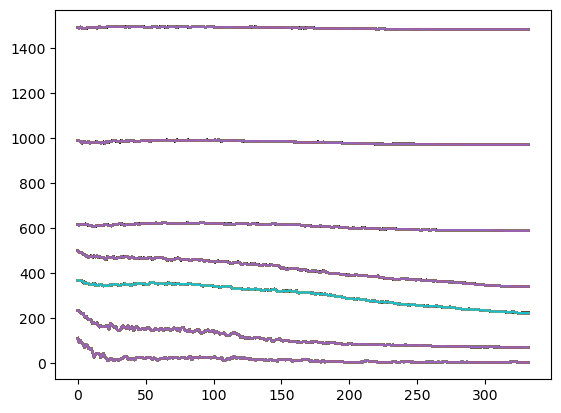

In [ ]:
# %%

fig,ax=plt.subplots()
for pth in pathlist:
    
    # find csv file
    data_path = None
    for file in Path(pth).rglob('*.csv'):
        if str(file.stem).endswith('lastFrame'):
            continue
        
        data_path = file
        break
    
    log_string = ''
    
    file_id,surfix,num_rods,AR,datetime_string = parse_path_string(data_path)
    time_line, node_list, contact_list = import_all_log(data_path,max_rows=100000)
    
    time_line = np.array(time_line)
    time_line = time_line[time_line <= 10]
    node_list = node_list[:len(time_line)]
    contact_list = contact_list[:len(time_line)]
    
    print(f'Size of time_line: {len(time_line)}')
    print(f'Number of rods: {num_rods}')
    
    log_string = log_string + f'Number of rods: {num_rods}\n'
    log_string = log_string + f'Number of time points: {len(time_line)}\n'
    
    output_path = f'{output_root}/{protocol_id}/{file_id}_{surfix}'
    if not os.path.exists(output_path):
        os.makedirs(output_path)
        start_point = 0
    else:
        start_point = len(glob.glob(f'{output_path}/*.png'))        
    start_point = 0
    nodes_in_matrix = node_list[0].reshape((-1,30))
    packing_center = np.mean(np.mean(nodes_in_matrix.reshape((-1,10,3)),axis=1),axis=0)
    
    locked_nodes = []
    for rr in nodes_in_matrix.reshape((-1,10,3)):
        I = np.linalg.norm(rr - packing_center,axis=1) < 0.1
        locked_nodes.append(rr[I,:])
    
    cluster_size = np.zeros((len(node_list)-1,num_rods),dtype=int)
    for i in range(1,len(node_list),1):
        nodes_in_matrix = node_list[i].reshape((-1,30))
        
        curr_contact_list = contact_list[i]
        curr_contact_list = curr_contact_list.reshape(-1,18)
        
        graph = nx.Graph()
        graph.add_nodes_from(range(num_rods))
        graph.add_edges_from(curr_contact_list[:,4:6])
        conn_comp = list(nx.connected_components(graph))        
        cl_size = [len(cc) for cc in conn_comp]        
        cluster_size[i-1] = max(cl_size)
        
    ax.plot(cluster_size)
    

# at edges between (idx1, idx3) and (idx2, idx4)
# (4 * idx1 + e1, contact_gradient[e1], idx5);
# (4 * idx3 + e1, contact_gradient[e1 + 3], idx5);
# (4 * idx2 + e1, contact_gradient[e1 + 6], idx6);
# (4 * idx4 + e1, contact_gradient[e1 + 9], idx6);

In [ ]:
pathlist

['/Users/yeonsu/Dropbox (Harvard University)/Data/from-cluster/HangEECarrotCake5/20240604-0050_RUN_HangEECarrotCake5_N125_AR25',
 '/Users/yeonsu/Dropbox (Harvard University)/Data/from-cluster/HangEECarrotCake5/20240604-0050_RUN_HangEECarrotCake5_N500_AR100',
 '/Users/yeonsu/Dropbox (Harvard University)/Data/from-cluster/HangEECarrotCake5/20240604-0110_RUN_HangEECarrotCake5_N250_AR50',
 '/Users/yeonsu/Dropbox (Harvard University)/Data/from-cluster/HangEECarrotCake5/20240604-0110_RUN_HangEECarrotCake5_N375_AR75',
 '/Users/yeonsu/Dropbox (Harvard University)/Data/from-cluster/HangEECarrotCake5/20240604-0110_RUN_HangEECarrotCake5_N625_AR125',
 '/Users/yeonsu/Dropbox (Harvard University)/Data/from-cluster/HangEECarrotCake5/20240604-0110_RUN_HangEECarrotCake5_N1000_AR200',
 '/Users/yeonsu/Dropbox (Harvard University)/Data/from-cluster/HangEECarrotCake5/20240604-0110_RUN_HangEECarrotCake5_N1500_AR300']

Size of time_line: 334
Number of rods: 125


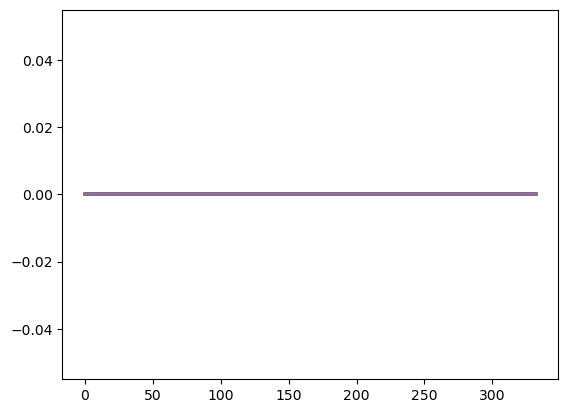

In [ ]:
# %%

fig,ax=plt.subplots()
for pth in pathlist:
    
    # find csv file
    data_path = None
    for file in Path(pth).rglob('*.csv'):
        if str(file.stem).endswith('lastFrame'):
            continue
        
        data_path = file
        break
    
    log_string = ''
    
    file_id,surfix,num_rods,AR,datetime_string = parse_path_string(data_path)
    time_line, node_list, contact_list = import_all_log(data_path,max_rows=100000)
    
    time_line = np.array(time_line)
    time_line = time_line[time_line <= 10]
    node_list = node_list[:len(time_line)]
    contact_list = contact_list[:len(time_line)]
    
    print(f'Size of time_line: {len(time_line)}')
    print(f'Number of rods: {num_rods}')
    
    log_string = log_string + f'Number of rods: {num_rods}\n'
    log_string = log_string + f'Number of time points: {len(time_line)}\n'
    
    output_path = f'{output_root}/{protocol_id}/{file_id}_{surfix}'
    if not os.path.exists(output_path):
        os.makedirs(output_path)
        start_point = 0
    else:
        start_point = len(glob.glob(f'{output_path}/*.png'))        
    start_point = 0
    nodes_in_matrix = node_list[0].reshape((-1,30))
    packing_center = np.mean(np.mean(nodes_in_matrix.reshape((-1,10,3)),axis=1),axis=0)
    
    locked_nodes = []
    for rr in nodes_in_matrix.reshape((-1,10,3)):
        I = np.linalg.norm(rr - packing_center,axis=1) < 0.1
        locked_nodes.append(rr[I,:])
    
    cluster_size = np.zeros((len(node_list)-1,num_rods),dtype=int)
    
    for i in range(1,len(node_list),1):
        nodes_in_matrix = node_list[i].reshape((-1,30))
        
        curr_contact_list = contact_list[i]
        curr_contact_list = curr_contact_list.reshape(-1,18)
        
        graph = nx.Graph()
        graph.add_nodes_from(range(num_rods))
        graph.add_edges_from(curr_contact_list[:,4:6])
        conn_comp = list(nx.connected_components(graph))        
        cl_size = [len(cc) for cc in conn_comp]        
        cluster_size[i-1] = max(cl_size)/num_rods
        
    ax.plot(cluster_size)
    break
    

# at edges between (idx1, idx3) and (idx2, idx4)
# (4 * idx1 + e1, contact_gradient[e1], idx5);
# (4 * idx3 + e1, contact_gradient[e1 + 3], idx5);
# (4 * idx2 + e1, contact_gradient[e1 + 6], idx6);
# (4 * idx4 + e1, contact_gradient[e1 + 9], idx6);

In [ ]:
cl_size

[1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1]

Size of time_line: 334
Number of rods: 125


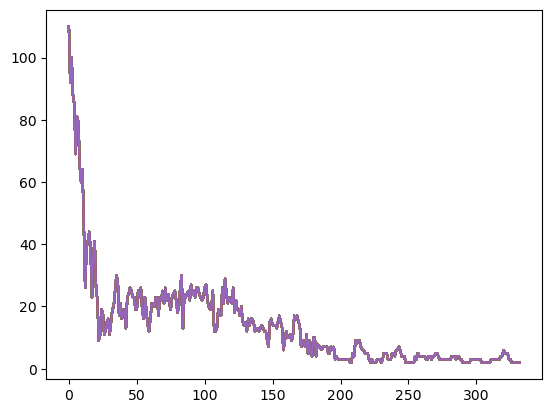

In [ ]:
# %%

fig,ax=plt.subplots()
for pth in pathlist:
    
    # find csv file
    data_path = None
    for file in Path(pth).rglob('*.csv'):
        if str(file.stem).endswith('lastFrame'):
            continue
        
        data_path = file
        break
    
    log_string = ''
    
    file_id,surfix,num_rods,AR,datetime_string = parse_path_string(data_path)
    time_line, node_list, contact_list = import_all_log(data_path,max_rows=100000)
    
    time_line = np.array(time_line)
    time_line = time_line[time_line <= 10]
    node_list = node_list[:len(time_line)]
    contact_list = contact_list[:len(time_line)]
    
    print(f'Size of time_line: {len(time_line)}')
    print(f'Number of rods: {num_rods}')
    
    log_string = log_string + f'Number of rods: {num_rods}\n'
    log_string = log_string + f'Number of time points: {len(time_line)}\n'
    
    output_path = f'{output_root}/{protocol_id}/{file_id}_{surfix}'
    if not os.path.exists(output_path):
        os.makedirs(output_path)
        start_point = 0
    else:
        start_point = len(glob.glob(f'{output_path}/*.png'))        
    start_point = 0
    nodes_in_matrix = node_list[0].reshape((-1,30))
    packing_center = np.mean(np.mean(nodes_in_matrix.reshape((-1,10,3)),axis=1),axis=0)
    
    locked_nodes = []
    for rr in nodes_in_matrix.reshape((-1,10,3)):
        I = np.linalg.norm(rr - packing_center,axis=1) < 0.1
        locked_nodes.append(rr[I,:])
    
    cluster_size = np.zeros((len(node_list)-1,num_rods),dtype=int)
    
    for i in range(1,len(node_list),1):
        nodes_in_matrix = node_list[i].reshape((-1,30))
        
        curr_contact_list = contact_list[i]
        curr_contact_list = curr_contact_list.reshape(-1,18)
        
        graph = nx.Graph()
        graph.add_nodes_from(range(num_rods))
        graph.add_edges_from(curr_contact_list[:,4:6])
        conn_comp = list(nx.connected_components(graph))        
        cl_size = [len(cc) for cc in conn_comp]        
        cluster_size[i-1] = max(cl_size)
        
    ax.plot(cluster_size)
    break
    

# at edges between (idx1, idx3) and (idx2, idx4)
# (4 * idx1 + e1, contact_gradient[e1], idx5);
# (4 * idx3 + e1, contact_gradient[e1 + 3], idx5);
# (4 * idx2 + e1, contact_gradient[e1 + 6], idx6);
# (4 * idx4 + e1, contact_gradient[e1 + 9], idx6);

In [ ]:
num_rods

125

Size of time_line: 334
Number of rods: 125


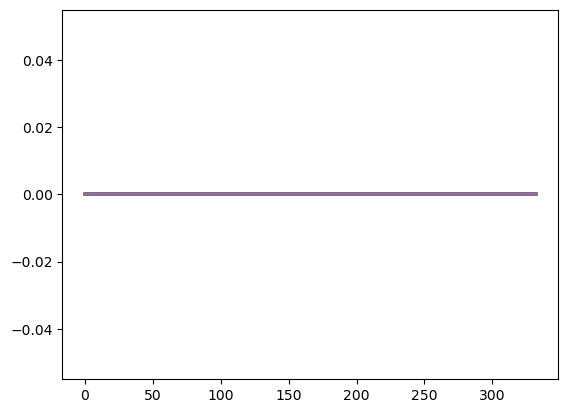

In [ ]:
# %%

fig,ax=plt.subplots()
for pth in pathlist:
    
    # find csv file
    data_path = None
    for file in Path(pth).rglob('*.csv'):
        if str(file.stem).endswith('lastFrame'):
            continue
        
        data_path = file
        break
    
    log_string = ''
    
    file_id,surfix,num_rods,AR,datetime_string = parse_path_string(data_path)
    time_line, node_list, contact_list = import_all_log(data_path,max_rows=100000)
    
    time_line = np.array(time_line)
    time_line = time_line[time_line <= 10]
    node_list = node_list[:len(time_line)]
    contact_list = contact_list[:len(time_line)]
    
    print(f'Size of time_line: {len(time_line)}')
    print(f'Number of rods: {num_rods}')
    
    log_string = log_string + f'Number of rods: {num_rods}\n'
    log_string = log_string + f'Number of time points: {len(time_line)}\n'
    
    output_path = f'{output_root}/{protocol_id}/{file_id}_{surfix}'
    if not os.path.exists(output_path):
        os.makedirs(output_path)
        start_point = 0
    else:
        start_point = len(glob.glob(f'{output_path}/*.png'))        
    start_point = 0
    nodes_in_matrix = node_list[0].reshape((-1,30))
    packing_center = np.mean(np.mean(nodes_in_matrix.reshape((-1,10,3)),axis=1),axis=0)
    
    locked_nodes = []
    for rr in nodes_in_matrix.reshape((-1,10,3)):
        I = np.linalg.norm(rr - packing_center,axis=1) < 0.1
        locked_nodes.append(rr[I,:])
    
    cluster_size = np.zeros((len(node_list)-1,num_rods),dtype=int)
    
    for i in range(1,len(node_list),1):
        nodes_in_matrix = node_list[i].reshape((-1,30))
        
        curr_contact_list = contact_list[i]
        curr_contact_list = curr_contact_list.reshape(-1,18)
        
        graph = nx.Graph()
        graph.add_nodes_from(range(num_rods))
        graph.add_edges_from(curr_contact_list[:,4:6])
        conn_comp = list(nx.connected_components(graph))        
        cl_size = [len(cc) for cc in conn_comp]        
        cluster_size[i-1] = max(cl_size)/num_rods
        
    ax.plot(cluster_size)
    break
    

# at edges between (idx1, idx3) and (idx2, idx4)
# (4 * idx1 + e1, contact_gradient[e1], idx5);
# (4 * idx3 + e1, contact_gradient[e1 + 3], idx5);
# (4 * idx2 + e1, contact_gradient[e1 + 6], idx6);
# (4 * idx4 + e1, contact_gradient[e1 + 9], idx6);

Size of time_line: 334
Number of rods: 125


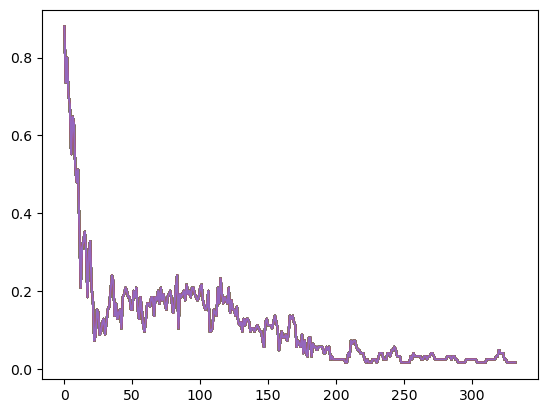

In [ ]:
# %%

fig,ax=plt.subplots()
for pth in pathlist:
    
    # find csv file
    data_path = None
    for file in Path(pth).rglob('*.csv'):
        if str(file.stem).endswith('lastFrame'):
            continue
        
        data_path = file
        break
    
    log_string = ''
    
    file_id,surfix,num_rods,AR,datetime_string = parse_path_string(data_path)
    time_line, node_list, contact_list = import_all_log(data_path,max_rows=100000)
    
    time_line = np.array(time_line)
    time_line = time_line[time_line <= 10]
    node_list = node_list[:len(time_line)]
    contact_list = contact_list[:len(time_line)]
    
    print(f'Size of time_line: {len(time_line)}')
    print(f'Number of rods: {num_rods}')
    
    log_string = log_string + f'Number of rods: {num_rods}\n'
    log_string = log_string + f'Number of time points: {len(time_line)}\n'
    
    output_path = f'{output_root}/{protocol_id}/{file_id}_{surfix}'
    if not os.path.exists(output_path):
        os.makedirs(output_path)
        start_point = 0
    else:
        start_point = len(glob.glob(f'{output_path}/*.png'))        
    start_point = 0
    nodes_in_matrix = node_list[0].reshape((-1,30))
    packing_center = np.mean(np.mean(nodes_in_matrix.reshape((-1,10,3)),axis=1),axis=0)
    
    locked_nodes = []
    for rr in nodes_in_matrix.reshape((-1,10,3)):
        I = np.linalg.norm(rr - packing_center,axis=1) < 0.1
        locked_nodes.append(rr[I,:])
    
    cluster_size = np.zeros((len(node_list)-1,num_rods),dtype=int)
    
    for i in range(1,len(node_list),1):
        nodes_in_matrix = node_list[i].reshape((-1,30))
        
        curr_contact_list = contact_list[i]
        curr_contact_list = curr_contact_list.reshape(-1,18)
        
        graph = nx.Graph()
        graph.add_nodes_from(range(num_rods))
        graph.add_edges_from(curr_contact_list[:,4:6])
        conn_comp = list(nx.connected_components(graph))        
        cl_size = [len(cc) for cc in conn_comp]        
        cluster_size[i-1] = max(cl_size)
        
    ax.plot(cluster_size/num_rods)
    break
    

# at edges between (idx1, idx3) and (idx2, idx4)
# (4 * idx1 + e1, contact_gradient[e1], idx5);
# (4 * idx3 + e1, contact_gradient[e1 + 3], idx5);
# (4 * idx2 + e1, contact_gradient[e1 + 6], idx6);
# (4 * idx4 + e1, contact_gradient[e1 + 9], idx6);

Size of time_line: 334
Number of rods: 125


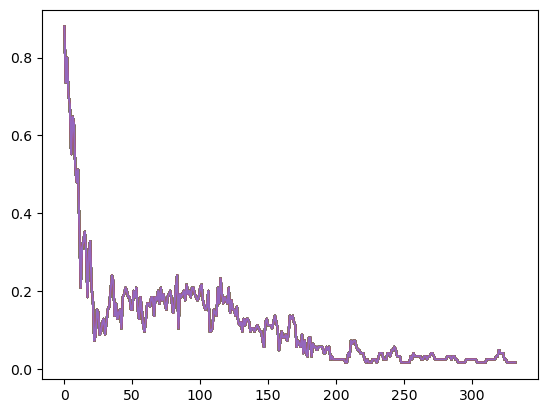

In [ ]:
# %%

fig,ax=plt.subplots()

for pth in pathlist:
    
    # find csv file
    data_path = None
    for file in Path(pth).rglob('*.csv'):
        if str(file.stem).endswith('lastFrame'):
            continue        
        data_path = file
        break
    
    log_string = ''
    
    file_id,surfix,num_rods,AR,datetime_string = parse_path_string(data_path)
    time_line, node_list, contact_list = import_all_log(data_path,max_rows=100000)
    
    time_line = np.array(time_line)
    time_line = time_line[time_line <= 10]
    node_list = node_list[:len(time_line)]
    contact_list = contact_list[:len(time_line)]
    
    print(f'Size of time_line: {len(time_line)}')
    print(f'Number of rods: {num_rods}')
    
    log_string = log_string + f'Number of rods: {num_rods}\n'
    log_string = log_string + f'Number of time points: {len(time_line)}\n'
    
    output_path = f'{output_root}/{protocol_id}/{file_id}_{surfix}'
    if not os.path.exists(output_path):
        os.makedirs(output_path)
        start_point = 0
    else:
        start_point = len(glob.glob(f'{output_path}/*.png'))        
    start_point = 0
    nodes_in_matrix = node_list[0].reshape((-1,30))
    packing_center = np.mean(np.mean(nodes_in_matrix.reshape((-1,10,3)),axis=1),axis=0)
    
    locked_nodes = []
    for rr in nodes_in_matrix.reshape((-1,10,3)):
        I = np.linalg.norm(rr - packing_center,axis=1) < 0.1
        locked_nodes.append(rr[I,:])
    
    cluster_size = np.zeros((len(node_list)-1,num_rods),dtype=int)
    
    for i in range(1,len(node_list),1):
        nodes_in_matrix = node_list[i].reshape((-1,30))
        
        curr_contact_list = contact_list[i]
        curr_contact_list = curr_contact_list.reshape(-1,18)
        
        graph = nx.Graph()
        graph.add_nodes_from(range(num_rods))
        graph.add_edges_from(curr_contact_list[:,4:6])
        conn_comp = list(nx.connected_components(graph))        
        cl_size = [len(cc) for cc in conn_comp]        
        cluster_size[i-1] = max(cl_size)
        
    ax.plot(cluster_size/num_rods)
    break
    

# at edges between (idx1, idx3) and (idx2, idx4)
# (4 * idx1 + e1, contact_gradient[e1], idx5);
# (4 * idx3 + e1, contact_gradient[e1 + 3], idx5);
# (4 * idx2 + e1, contact_gradient[e1 + 6], idx6);
# (4 * idx4 + e1, contact_gradient[e1 + 9], idx6);

Size of time_line: 334
Number of rods: 125


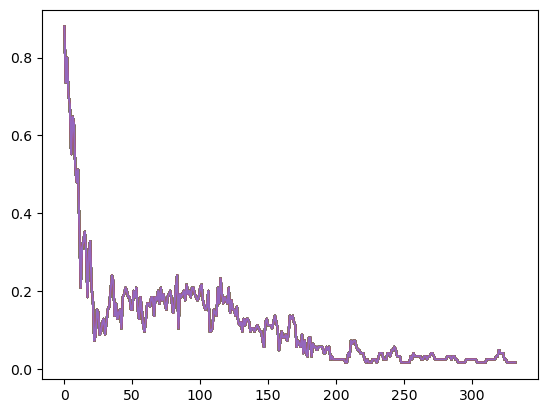

In [ ]:
# %%

fig,ax=plt.subplots()

for pth in pathlist:
    
    # find csv file
    data_path = None
    for file in Path(pth).rglob('*.csv'):
        if str(file.stem).endswith('lastFrame'):
            continue        
        data_path = file
        break
    
    log_string = ''
    
    file_id,surfix,num_rods,AR,datetime_string = parse_path_string(data_path)
    time_line, node_list, contact_list = import_all_log(data_path,max_rows=100000)
    
    time_line = np.array(time_line)
    time_line = time_line[time_line <= 10]
    node_list = node_list[:len(time_line)]
    contact_list = contact_list[:len(time_line)]
    
    print(f'Size of time_line: {len(time_line)}')
    print(f'Number of rods: {num_rods}')
    
    log_string = log_string + f'Number of rods: {num_rods}\n'
    log_string = log_string + f'Number of time points: {len(time_line)}\n'
    
    output_path = f'{output_root}/{protocol_id}/{file_id}_{surfix}'
    if not os.path.exists(output_path):
        os.makedirs(output_path)
        start_point = 0
    else:
        start_point = len(glob.glob(f'{output_path}/*.png'))        
    start_point = 0
    nodes_in_matrix = node_list[0].reshape((-1,30))
    packing_center = np.mean(np.mean(nodes_in_matrix.reshape((-1,10,3)),axis=1),axis=0)
    
    locked_nodes = []
    for rr in nodes_in_matrix.reshape((-1,10,3)):
        I = np.linalg.norm(rr - packing_center,axis=1) < 0.1
        locked_nodes.append(rr[I,:])
    
    cluster_size = np.zeros((len(node_list)-1,num_rods),dtype=int)
    
    for i in range(1,len(node_list),1):
        nodes_in_matrix = node_list[i].reshape((-1,30))
        
        curr_contact_list = contact_list[i]
        curr_contact_list = curr_contact_list.reshape(-1,18)
        
        graph = nx.Graph()
        graph.add_nodes_from(range(num_rods))
        graph.add_edges_from(curr_contact_list[:,4:6])
        conn_comp = list(nx.connected_components(graph))        
        cl_size = [len(cc) for cc in conn_comp]        
        cluster_size[i-1] = max(cl_size)
        
    ax.plot(cluster_size/num_rods)
    break
    

# at edges between (idx1, idx3) and (idx2, idx4)
# (4 * idx1 + e1, contact_gradient[e1], idx5);
# (4 * idx3 + e1, contact_gradient[e1 + 3], idx5);
# (4 * idx2 + e1, contact_gradient[e1 + 6], idx6);
# (4 * idx4 + e1, contact_gradient[e1 + 9], idx6);

Size of time_line: 334
Number of rods: 125


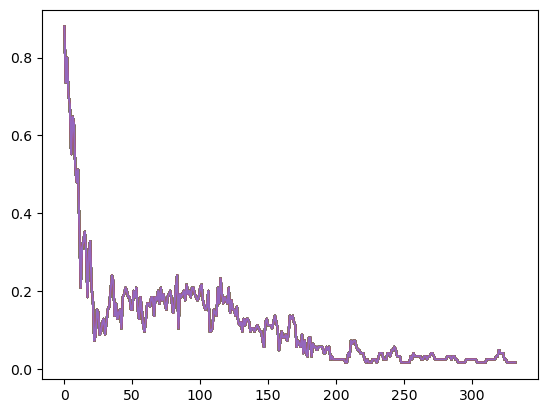

In [ ]:
# %%

fig,ax=plt.subplots()

for pth in pathlist:
    
    # find csv file
    data_path = None
    for file in Path(pth).rglob('*.csv'):
        if str(file.stem).endswith('lastFrame'):
            continue        
        data_path = file
        break
    
    log_string = ''
    
    file_id,surfix,num_rods,AR,datetime_string = parse_path_string(data_path)
    time_line, node_list, contact_list = import_all_log(data_path,max_rows=100000)
    
    time_line = np.array(time_line)
    time_line = time_line[time_line <= 10]
    node_list = node_list[:len(time_line)]
    contact_list = contact_list[:len(time_line)]
    
    print(f'Size of time_line: {len(time_line)}')
    print(f'Number of rods: {num_rods}')
    
    log_string = log_string + f'Number of rods: {num_rods}\n'
    log_string = log_string + f'Number of time points: {len(time_line)}\n'
    
    output_path = f'{output_root}/{protocol_id}/{file_id}_{surfix}'
    if not os.path.exists(output_path):
        os.makedirs(output_path)
        start_point = 0
    else:
        start_point = len(glob.glob(f'{output_path}/*.png'))        
    start_point = 0
    nodes_in_matrix = node_list[0].reshape((-1,30))
    packing_center = np.mean(np.mean(nodes_in_matrix.reshape((-1,10,3)),axis=1),axis=0)
    
    # locked_nodes = []
    # for rr in nodes_in_matrix.reshape((-1,10,3)):
    #     I = np.linalg.norm(rr - packing_center,axis=1) < 0.1
    #     locked_nodes.append(rr[I,:])
    
    cluster_size = np.zeros((len(node_list)-1,num_rods),dtype=int)
    
    for i in range(1,len(node_list),1):
        nodes_in_matrix = node_list[i].reshape((-1,30))
        
        curr_contact_list = contact_list[i]
        curr_contact_list = curr_contact_list.reshape(-1,18)
        
        graph = nx.Graph()
        graph.add_nodes_from(range(num_rods))
        graph.add_edges_from(curr_contact_list[:,4:6])
        conn_comp = list(nx.connected_components(graph))        
        cl_size = [len(cc) for cc in conn_comp]        
        cluster_size[i-1] = max(cl_size)
        
    ax.plot(cluster_size/num_rods)
    break
    

# at edges between (idx1, idx3) and (idx2, idx4)
# (4 * idx1 + e1, contact_gradient[e1], idx5);
# (4 * idx3 + e1, contact_gradient[e1 + 3], idx5);
# (4 * idx2 + e1, contact_gradient[e1 + 6], idx6);
# (4 * idx4 + e1, contact_gradient[e1 + 9], idx6);

Size of time_line: 334
Number of rods: 125


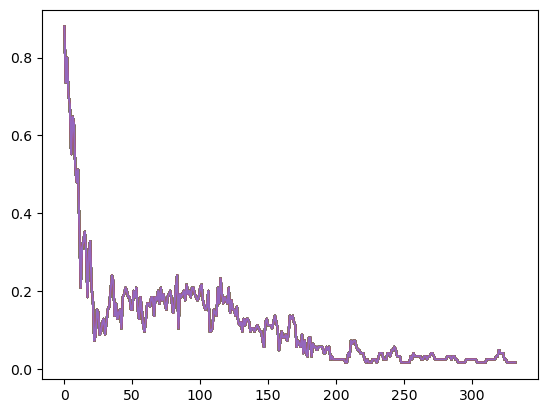

In [ ]:
# %%

fig,ax=plt.subplots()

for pth in pathlist:
    
    # find csv file
    data_path = None
    for file in Path(pth).rglob('*.csv'):
        if str(file.stem).endswith('lastFrame'):
            continue        
        data_path = file
        break
    
    log_string = ''
    
    file_id,surfix,num_rods,AR,datetime_string = parse_path_string(data_path)
    time_line, node_list, contact_list = import_all_log(data_path,max_rows=100000)
    
    time_line = np.array(time_line)
    time_line = time_line[time_line <= 10]
    node_list = node_list[:len(time_line)]
    contact_list = contact_list[:len(time_line)]
    
    print(f'Size of time_line: {len(time_line)}')
    print(f'Number of rods: {num_rods}')
    
    log_string = log_string + f'Number of rods: {num_rods}\n'
    log_string = log_string + f'Number of time points: {len(time_line)}\n'
    
    output_path = f'{output_root}/{protocol_id}/{file_id}_{surfix}'
    if not os.path.exists(output_path):
        os.makedirs(output_path)
        start_point = 0
    else:
        start_point = len(glob.glob(f'{output_path}/*.png'))        
    start_point = 0
    nodes_in_matrix = node_list[0].reshape((-1,30))
    packing_center = np.mean(np.mean(nodes_in_matrix.reshape((-1,10,3)),axis=1),axis=0)
    
    # locked_nodes = []
    # for rr in nodes_in_matrix.reshape((-1,10,3)):
    #     I = np.linalg.norm(rr - packing_center,axis=1) < 0.1
    #     locked_nodes.append(rr[I,:])
    
    cluster_size = np.zeros((len(node_list)-1,num_rods),dtype=int)
    
    for i in range(1,len(node_list),1):
        nodes_in_matrix = node_list[i].reshape((-1,30))
        
        curr_contact_list = contact_list[i]
        curr_contact_list = curr_contact_list.reshape(-1,18)
        
        graph = nx.Graph()
        graph.add_nodes_from(range(num_rods))
        graph.add_edges_from(curr_contact_list[:,4:6])
        conn_comp = list(nx.connected_components(graph))        
        cl_size = [len(cc) for cc in conn_comp]        
        cluster_size[i-1] = max(cl_size)
        
    ax.plot(cluster_size/num_rods)
    break
    

# at edges between (idx1, idx3) and (idx2, idx4)
# (4 * idx1 + e1, contact_gradient[e1], idx5);
# (4 * idx3 + e1, contact_gradient[e1 + 3], idx5);
# (4 * idx2 + e1, contact_gradient[e1 + 6], idx6);
# (4 * idx4 + e1, contact_gradient[e1 + 9], idx6);

Size of time_line: 334
Number of rods: 125
Size of time_line: 334
Number of rods: 500
Size of time_line: 334
Number of rods: 250
Size of time_line: 334
Number of rods: 375
Size of time_line: 334
Number of rods: 625
Size of time_line: 334
Number of rods: 1000
Size of time_line: 334
Number of rods: 1500


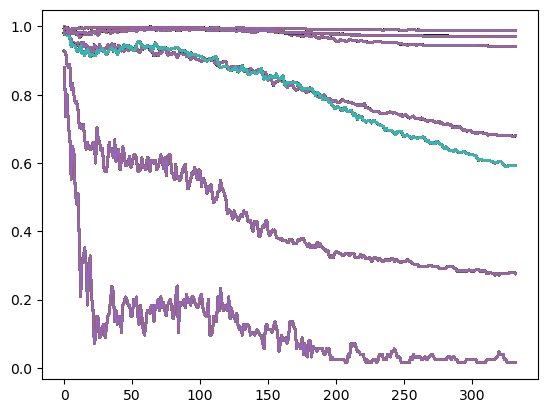

In [ ]:
# %%

fig,ax=plt.subplots()

for pth in pathlist:
    
    # find csv file
    data_path = None
    for file in Path(pth).rglob('*.csv'):
        if str(file.stem).endswith('lastFrame'):
            continue        
        data_path = file
        break
    
    log_string = ''
    
    file_id,surfix,num_rods,AR,datetime_string = parse_path_string(data_path)
    time_line, node_list, contact_list = import_all_log(data_path,max_rows=100000)
    
    time_line = np.array(time_line)
    time_line = time_line[time_line <= 10]
    node_list = node_list[:len(time_line)]
    contact_list = contact_list[:len(time_line)]
    
    print(f'Size of time_line: {len(time_line)}')
    print(f'Number of rods: {num_rods}')
    
    log_string = log_string + f'Number of rods: {num_rods}\n'
    log_string = log_string + f'Number of time points: {len(time_line)}\n'
    
    output_path = f'{output_root}/{protocol_id}/{file_id}_{surfix}'
    if not os.path.exists(output_path):
        os.makedirs(output_path)
        start_point = 0
    else:
        start_point = len(glob.glob(f'{output_path}/*.png'))        
    start_point = 0
    nodes_in_matrix = node_list[0].reshape((-1,30))
    packing_center = np.mean(np.mean(nodes_in_matrix.reshape((-1,10,3)),axis=1),axis=0)
    
    # locked_nodes = []
    # for rr in nodes_in_matrix.reshape((-1,10,3)):
    #     I = np.linalg.norm(rr - packing_center,axis=1) < 0.1
    #     locked_nodes.append(rr[I,:])
    
    cluster_size = np.zeros((len(node_list)-1,num_rods),dtype=int)
    
    for i in range(1,len(node_list),1):
        nodes_in_matrix = node_list[i].reshape((-1,30))
        
        curr_contact_list = contact_list[i]
        curr_contact_list = curr_contact_list.reshape(-1,18)
        
        graph = nx.Graph()
        graph.add_nodes_from(range(num_rods))
        graph.add_edges_from(curr_contact_list[:,4:6])
        conn_comp = list(nx.connected_components(graph))        
        cl_size = [len(cc) for cc in conn_comp]        
        cluster_size[i-1] = max(cl_size)
        
    ax.plot(cluster_size/num_rods)
    # break
    

# at edges between (idx1, idx3) and (idx2, idx4)
# (4 * idx1 + e1, contact_gradient[e1], idx5);
# (4 * idx3 + e1, contact_gradient[e1 + 3], idx5);
# (4 * idx2 + e1, contact_gradient[e1 + 6], idx6);
# (4 * idx4 + e1, contact_gradient[e1 + 9], idx6);

In [ ]:
cluster_size

array([[1492, 1492, 1492, ..., 1492, 1492, 1492],
       [1489, 1489, 1489, ..., 1489, 1489, 1489],
       [1495, 1495, 1495, ..., 1495, 1495, 1495],
       ...,
       [1484, 1484, 1484, ..., 1484, 1484, 1484],
       [1484, 1484, 1484, ..., 1484, 1484, 1484],
       [1484, 1484, 1484, ..., 1484, 1484, 1484]])

Size of time_line: 334
Number of rods: 125
Size of time_line: 334
Number of rods: 500
Size of time_line: 334
Number of rods: 250
Size of time_line: 334
Number of rods: 375
Size of time_line: 334
Number of rods: 625
Size of time_line: 334
Number of rods: 1000
Size of time_line: 334
Number of rods: 1500


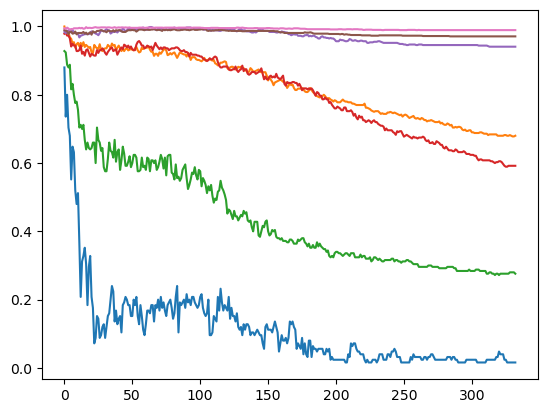

In [ ]:
# %%

fig,ax=plt.subplots()

for pth in pathlist:
    
    # find csv file
    data_path = None
    for file in Path(pth).rglob('*.csv'):
        if str(file.stem).endswith('lastFrame'):
            continue        
        data_path = file
        break
    
    log_string = ''
    
    file_id,surfix,num_rods,AR,datetime_string = parse_path_string(data_path)
    time_line, node_list, contact_list = import_all_log(data_path,max_rows=100000)
    
    time_line = np.array(time_line)
    time_line = time_line[time_line <= 10]
    node_list = node_list[:len(time_line)]
    contact_list = contact_list[:len(time_line)]
    
    print(f'Size of time_line: {len(time_line)}')
    print(f'Number of rods: {num_rods}')
    
    log_string = log_string + f'Number of rods: {num_rods}\n'
    log_string = log_string + f'Number of time points: {len(time_line)}\n'
    
    output_path = f'{output_root}/{protocol_id}/{file_id}_{surfix}'
    if not os.path.exists(output_path):
        os.makedirs(output_path)
        start_point = 0
    else:
        start_point = len(glob.glob(f'{output_path}/*.png'))        
    start_point = 0
    nodes_in_matrix = node_list[0].reshape((-1,30))
    packing_center = np.mean(np.mean(nodes_in_matrix.reshape((-1,10,3)),axis=1),axis=0)
    
    # locked_nodes = []
    # for rr in nodes_in_matrix.reshape((-1,10,3)):
    #     I = np.linalg.norm(rr - packing_center,axis=1) < 0.1
    #     locked_nodes.append(rr[I,:])
    
    cluster_size = np.zeros((len(node_list)-1),dtype=int)
    
    for i in range(1,len(node_list),1):
        nodes_in_matrix = node_list[i].reshape((-1,30))
        
        curr_contact_list = contact_list[i]
        curr_contact_list = curr_contact_list.reshape(-1,18)
        
        graph = nx.Graph()
        graph.add_nodes_from(range(num_rods))
        graph.add_edges_from(curr_contact_list[:,4:6])
        conn_comp = list(nx.connected_components(graph))        
        cl_size = [len(cc) for cc in conn_comp]        
        cluster_size[i-1] = max(cl_size)
        
    ax.plot(cluster_size/num_rods)
    # break
    

# at edges between (idx1, idx3) and (idx2, idx4)
# (4 * idx1 + e1, contact_gradient[e1], idx5);
# (4 * idx3 + e1, contact_gradient[e1 + 3], idx5);
# (4 * idx2 + e1, contact_gradient[e1 + 6], idx6);
# (4 * idx4 + e1, contact_gradient[e1 + 9], idx6);

In [ ]:
# %%

output_root = '/Users/yeonsu/Dropbox (Harvard University)/Data/PrunedData/rod-sim-pnas-revision'

# Jostle
protocol_id = 'HangEECarrotCake5'

pathlist = []
pathlist.append('/Users/yeonsu/Dropbox (Harvard University)/Data/from-cluster/HangEECarrotCake5/20240604-0050_RUN_HangEECarrotCake5_N125_AR25')
pathlist.append('/Users/yeonsu/Dropbox (Harvard University)/Data/from-cluster/HangEECarrotCake5/20240604-0110_RUN_HangEECarrotCake5_N250_AR50')
pathlist.append('/Users/yeonsu/Dropbox (Harvard University)/Data/from-cluster/HangEECarrotCake5/20240604-0110_RUN_HangEECarrotCake5_N375_AR75')
pathlist.append('/Users/yeonsu/Dropbox (Harvard University)/Data/from-cluster/HangEECarrotCake5/20240604-0050_RUN_HangEECarrotCake5_N500_AR100')
pathlist.append('/Users/yeonsu/Dropbox (Harvard University)/Data/from-cluster/HangEECarrotCake5/20240604-0110_RUN_HangEECarrotCake5_N625_AR125')
pathlist.append('/Users/yeonsu/Dropbox (Harvard University)/Data/from-cluster/HangEECarrotCake5/20240604-0110_RUN_HangEECarrotCake5_N1000_AR200')
pathlist.append('/Users/yeonsu/Dropbox (Harvard University)/Data/from-cluster/HangEECarrotCake5/20240604-0110_RUN_HangEECarrotCake5_N1500_AR300')

# for pth in pathlist:    
#     # find csv file
#     data_path = None
#     for file in Path(pth).rglob('*.csv'):
#         if str(file.stem).endswith('lastFrame'):
#             continue
        
#         data_path = file
#         break
    
#     log_string = ''
    
#     file_id,surfix,num_rods,AR,datetime_string = parse_path_string(data_path)
#     time_line, node_list, contact_list = import_all_log(data_path,max_rows=100000)
    
#     time_line = np.array(time_line)
#     time_line = time_line[time_line <= 10]
#     node_list = node_list[:len(time_line)]
#     contact_list = contact_list[:len(time_line)]
    
#     print(f'Size of time_line: {len(time_line)}')
#     print(f'Number of rods: {num_rods}')
    
#     log_string = log_string + f'Number of rods: {num_rods}\n'
#     log_string = log_string + f'Number of time points: {len(time_line)}\n'
    
#     output_path = f'{output_root}/{protocol_id}/{file_id}_{surfix}'
#     if not os.path.exists(output_path):
#         os.makedirs(output_path)
#         start_point = 0
#     else:
#         start_point = len(glob.glob(f'{output_path}/*.png'))        
        
#     nodes_in_matrix = node_list[0].reshape((-1,30))
#     packing_center = np.mean(np.mean(nodes_in_matrix.reshape((-1,10,3)),axis=1),axis=0)
    
    
#     fig,ax=plt.subplots(subplot_kw={'projection':'3d'})
#     locked_nodes = []
#     for rr in nodes_in_matrix.reshape((-1,10,3)):
#         I = np.linalg.norm(rr - packing_center,axis=1) < 0.1
#         # ax.plot(rr[I,0],rr[I,1],rr[I,2],'k-')
#         locked_nodes.append(rr[I,:])
        
#     print(f'Number of locked nodes: {len(locked_nodes)}')
    
#     for i in range(start_point,len(node_list),1):
#         nodes_in_matrix = node_list[i].reshape((-1,30))
#         for node in nodes_in_matrix:
#             rr = node.reshape((-1,3))
#             ax.plot(rr[:,0],rr[:,1],rr[:,2],alpha=0.1)
            
#         for rr in locked_nodes:
#             ax.plot(rr[:,0],rr[:,1],rr[:,2],'k-',linewidth=2)
            
#         ax.set_xlim(-2,2)
#         ax.set_ylim(-2,2)
#         ax.set_zlim(-2,2)
#         ax.view_init(elev=0,azim=0)
#         ax.text(1,1,1,f'time: {time_line[i]}')
#         plt.tight_layout(pad=0)
        
#         plt.savefig(f'{output_path}/frames_{i:04d}.png', dpi=300, bbox_inches='tight', pad_inches=0)
#         ax.clear()
        
#     with open(f'{output_path}/log.txt','w') as f:
#         f.write(log_string)

Size of time_line: 334
Number of rods: 125


AttributeError: module 'matplotlib.pyplot' has no attribute 'label'

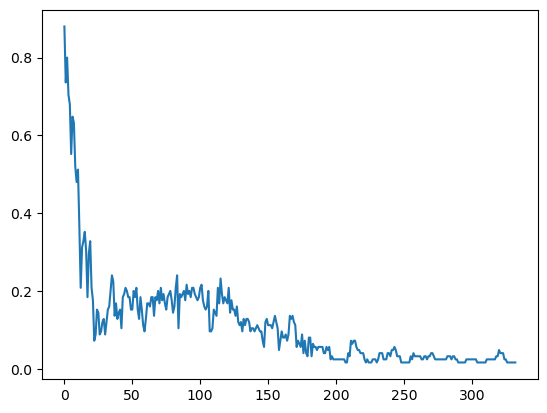

In [ ]:
# %%

fig,ax=plt.subplots()

for pth in pathlist:
    
    # find csv file
    data_path = None
    for file in Path(pth).rglob('*.csv'):
        if str(file.stem).endswith('lastFrame'):
            continue        
        data_path = file
        break
    
    log_string = ''
    
    file_id,surfix,num_rods,AR,datetime_string = parse_path_string(data_path)
    time_line, node_list, contact_list = import_all_log(data_path,max_rows=100000)
    
    time_line = np.array(time_line)
    time_line = time_line[time_line <= 10]
    node_list = node_list[:len(time_line)]
    contact_list = contact_list[:len(time_line)]
    
    print(f'Size of time_line: {len(time_line)}')
    print(f'Number of rods: {num_rods}')
    
    log_string = log_string + f'Number of rods: {num_rods}\n'
    log_string = log_string + f'Number of time points: {len(time_line)}\n'
    
    output_path = f'{output_root}/{protocol_id}/{file_id}_{surfix}'
    if not os.path.exists(output_path):
        os.makedirs(output_path)
        start_point = 0
    else:
        start_point = len(glob.glob(f'{output_path}/*.png'))        
    start_point = 0
    nodes_in_matrix = node_list[0].reshape((-1,30))
    packing_center = np.mean(np.mean(nodes_in_matrix.reshape((-1,10,3)),axis=1),axis=0)
    
    # locked_nodes = []
    # for rr in nodes_in_matrix.reshape((-1,10,3)):
    #     I = np.linalg.norm(rr - packing_center,axis=1) < 0.1
    #     locked_nodes.append(rr[I,:])
    
    cluster_size = np.zeros((len(node_list)-1),dtype=int)
    
    for i in range(1,len(node_list),1):
        nodes_in_matrix = node_list[i].reshape((-1,30))
        
        curr_contact_list = contact_list[i]
        curr_contact_list = curr_contact_list.reshape(-1,18)
        
        graph = nx.Graph()
        graph.add_nodes_from(range(num_rods))
        graph.add_edges_from(curr_contact_list[:,4:6])
        conn_comp = list(nx.connected_components(graph))        
        cl_size = [len(cc) for cc in conn_comp]        
        cluster_size[i-1] = max(cl_size)
        
    ax.plot(cluster_size/num_rods,label=f'AR = {AR}, N = {num_rods}')
    break

plt.label()
    

# at edges between (idx1, idx3) and (idx2, idx4)
# (4 * idx1 + e1, contact_gradient[e1], idx5);
# (4 * idx3 + e1, contact_gradient[e1 + 3], idx5);
# (4 * idx2 + e1, contact_gradient[e1 + 6], idx6);
# (4 * idx4 + e1, contact_gradient[e1 + 9], idx6);

Size of time_line: 334
Number of rods: 125


AttributeError: module 'matplotlib.pyplot' has no attribute 'label'

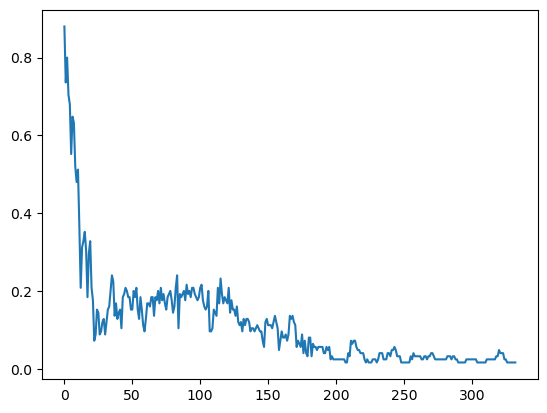

In [ ]:
# %%

fig,ax=plt.subplots()

for pth in pathlist:
    
    # find csv file
    data_path = None
    for file in Path(pth).rglob('*.csv'):
        if str(file.stem).endswith('lastFrame'):
            continue        
        data_path = file
        break
    
    log_string = ''
    
    file_id,surfix,num_rods,AR,datetime_string = parse_path_string(data_path)
    time_line, node_list, contact_list = import_all_log(data_path,max_rows=100000)
    
    time_line = np.array(time_line)
    time_line = time_line[time_line <= 10]
    node_list = node_list[:len(time_line)]
    contact_list = contact_list[:len(time_line)]
    
    print(f'Size of time_line: {len(time_line)}')
    print(f'Number of rods: {num_rods}')
    
    log_string = log_string + f'Number of rods: {num_rods}\n'
    log_string = log_string + f'Number of time points: {len(time_line)}\n'
    
    output_path = f'{output_root}/{protocol_id}/{file_id}_{surfix}'
    if not os.path.exists(output_path):
        os.makedirs(output_path)
        start_point = 0
    else:
        start_point = len(glob.glob(f'{output_path}/*.png'))        
    start_point = 0
    nodes_in_matrix = node_list[0].reshape((-1,30))
    packing_center = np.mean(np.mean(nodes_in_matrix.reshape((-1,10,3)),axis=1),axis=0)
    
    # locked_nodes = []
    # for rr in nodes_in_matrix.reshape((-1,10,3)):
    #     I = np.linalg.norm(rr - packing_center,axis=1) < 0.1
    #     locked_nodes.append(rr[I,:])
    
    cluster_size = np.zeros((len(node_list)-1),dtype=int)
    
    for i in range(1,len(node_list),1):
        nodes_in_matrix = node_list[i].reshape((-1,30))
        
        curr_contact_list = contact_list[i]
        curr_contact_list = curr_contact_list.reshape(-1,18)
        
        graph = nx.Graph()
        graph.add_nodes_from(range(num_rods))
        graph.add_edges_from(curr_contact_list[:,4:6])
        conn_comp = list(nx.connected_components(graph))        
        cl_size = [len(cc) for cc in conn_comp]        
        cluster_size[i-1] = max(cl_size)
        
    ax.plot(cluster_size/num_rods,label=f'AR = {AR}, N = {num_rods}')
    break

plt.label()
    

# at edges between (idx1, idx3) and (idx2, idx4)
# (4 * idx1 + e1, contact_gradient[e1], idx5);
# (4 * idx3 + e1, contact_gradient[e1 + 3], idx5);
# (4 * idx2 + e1, contact_gradient[e1 + 6], idx6);
# (4 * idx4 + e1, contact_gradient[e1 + 9], idx6);

Size of time_line: 334
Number of rods: 125


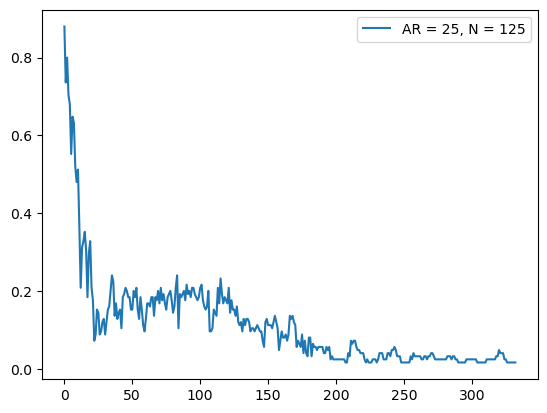

In [ ]:
# %%

fig,ax=plt.subplots()

for pth in pathlist:
    
    # find csv file
    data_path = None
    for file in Path(pth).rglob('*.csv'):
        if str(file.stem).endswith('lastFrame'):
            continue        
        data_path = file
        break
    
    log_string = ''
    
    file_id,surfix,num_rods,AR,datetime_string = parse_path_string(data_path)
    time_line, node_list, contact_list = import_all_log(data_path,max_rows=100000)
    
    time_line = np.array(time_line)
    time_line = time_line[time_line <= 10]
    node_list = node_list[:len(time_line)]
    contact_list = contact_list[:len(time_line)]
    
    print(f'Size of time_line: {len(time_line)}')
    print(f'Number of rods: {num_rods}')
    
    log_string = log_string + f'Number of rods: {num_rods}\n'
    log_string = log_string + f'Number of time points: {len(time_line)}\n'
    
    output_path = f'{output_root}/{protocol_id}/{file_id}_{surfix}'
    if not os.path.exists(output_path):
        os.makedirs(output_path)
        start_point = 0
    else:
        start_point = len(glob.glob(f'{output_path}/*.png'))        
    start_point = 0
    nodes_in_matrix = node_list[0].reshape((-1,30))
    packing_center = np.mean(np.mean(nodes_in_matrix.reshape((-1,10,3)),axis=1),axis=0)
    
    # locked_nodes = []
    # for rr in nodes_in_matrix.reshape((-1,10,3)):
    #     I = np.linalg.norm(rr - packing_center,axis=1) < 0.1
    #     locked_nodes.append(rr[I,:])
    
    cluster_size = np.zeros((len(node_list)-1),dtype=int)
    
    for i in range(1,len(node_list),1):
        nodes_in_matrix = node_list[i].reshape((-1,30))
        
        curr_contact_list = contact_list[i]
        curr_contact_list = curr_contact_list.reshape(-1,18)
        
        graph = nx.Graph()
        graph.add_nodes_from(range(num_rods))
        graph.add_edges_from(curr_contact_list[:,4:6])
        conn_comp = list(nx.connected_components(graph))        
        cl_size = [len(cc) for cc in conn_comp]        
        cluster_size[i-1] = max(cl_size)
        
    ax.plot(cluster_size/num_rods,label=f'AR = {AR}, N = {num_rods}')
    break

plt.legend()
    

# at edges between (idx1, idx3) and (idx2, idx4)
# (4 * idx1 + e1, contact_gradient[e1], idx5);
# (4 * idx3 + e1, contact_gradient[e1 + 3], idx5);
# (4 * idx2 + e1, contact_gradient[e1 + 6], idx6);
# (4 * idx4 + e1, contact_gradient[e1 + 9], idx6);

Size of time_line: 334
Number of rods: 125


Text(0.5, 0, 'Time (sec)')

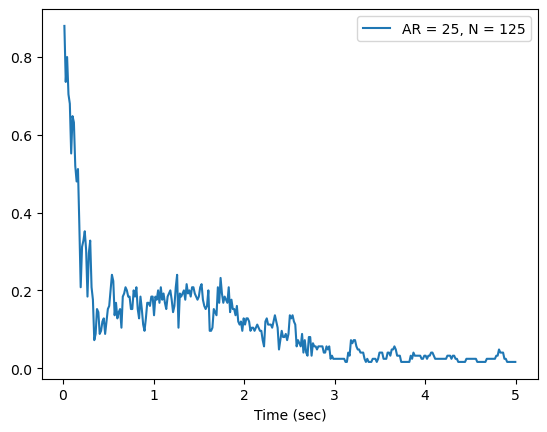

In [ ]:
# %%

fig,ax=plt.subplots()

for pth in pathlist:
    
    # find csv file
    data_path = None
    for file in Path(pth).rglob('*.csv'):
        if str(file.stem).endswith('lastFrame'):
            continue        
        data_path = file
        break
    
    log_string = ''
    
    file_id,surfix,num_rods,AR,datetime_string = parse_path_string(data_path)
    time_line, node_list, contact_list = import_all_log(data_path,max_rows=100000)
    
    time_line = np.array(time_line)
    time_line = time_line[time_line <= 10]
    node_list = node_list[:len(time_line)]
    contact_list = contact_list[:len(time_line)]
    
    print(f'Size of time_line: {len(time_line)}')
    print(f'Number of rods: {num_rods}')
    
    log_string = log_string + f'Number of rods: {num_rods}\n'
    log_string = log_string + f'Number of time points: {len(time_line)}\n'
    
    output_path = f'{output_root}/{protocol_id}/{file_id}_{surfix}'
    if not os.path.exists(output_path):
        os.makedirs(output_path)
        start_point = 0
    else:
        start_point = len(glob.glob(f'{output_path}/*.png'))        
    start_point = 0
    nodes_in_matrix = node_list[0].reshape((-1,30))
    packing_center = np.mean(np.mean(nodes_in_matrix.reshape((-1,10,3)),axis=1),axis=0)
    
    # locked_nodes = []
    # for rr in nodes_in_matrix.reshape((-1,10,3)):
    #     I = np.linalg.norm(rr - packing_center,axis=1) < 0.1
    #     locked_nodes.append(rr[I,:])
    
    cluster_size = np.zeros((len(node_list)-1),dtype=int)
    
    for i in range(1,len(node_list),1):
        nodes_in_matrix = node_list[i].reshape((-1,30))
        
        curr_contact_list = contact_list[i]
        curr_contact_list = curr_contact_list.reshape(-1,18)
        
        graph = nx.Graph()
        graph.add_nodes_from(range(num_rods))
        graph.add_edges_from(curr_contact_list[:,4:6])
        conn_comp = list(nx.connected_components(graph))        
        cl_size = [len(cc) for cc in conn_comp]        
        cluster_size[i-1] = max(cl_size)
        
    ax.plot(time_line[1:],cluster_size/num_rods,label=f'AR = {AR}, N = {num_rods}')
    break

plt.legend()
plt.xlabel('Time (sec)')
    

# at edges between (idx1, idx3) and (idx2, idx4)
# (4 * idx1 + e1, contact_gradient[e1], idx5);
# (4 * idx3 + e1, contact_gradient[e1 + 3], idx5);
# (4 * idx2 + e1, contact_gradient[e1 + 6], idx6);
# (4 * idx4 + e1, contact_gradient[e1 + 9], idx6);

Size of time_line: 334
Number of rods: 125


Text(0, 0.5, 'Fraction of largest cluster')

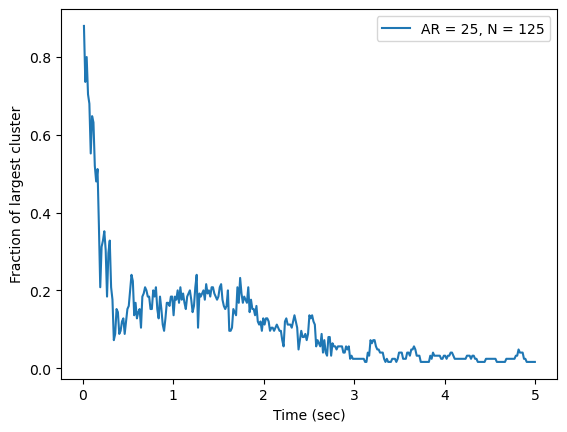

In [ ]:
# %%

fig,ax=plt.subplots()

for pth in pathlist:
    
    # find csv file
    data_path = None
    for file in Path(pth).rglob('*.csv'):
        if str(file.stem).endswith('lastFrame'):
            continue        
        data_path = file
        break
    
    log_string = ''
    
    file_id,surfix,num_rods,AR,datetime_string = parse_path_string(data_path)
    time_line, node_list, contact_list = import_all_log(data_path,max_rows=100000)
    
    time_line = np.array(time_line)
    time_line = time_line[time_line <= 10]
    node_list = node_list[:len(time_line)]
    contact_list = contact_list[:len(time_line)]
    
    print(f'Size of time_line: {len(time_line)}')
    print(f'Number of rods: {num_rods}')
    
    log_string = log_string + f'Number of rods: {num_rods}\n'
    log_string = log_string + f'Number of time points: {len(time_line)}\n'
    
    output_path = f'{output_root}/{protocol_id}/{file_id}_{surfix}'
    if not os.path.exists(output_path):
        os.makedirs(output_path)
        start_point = 0
    else:
        start_point = len(glob.glob(f'{output_path}/*.png'))        
    start_point = 0
    nodes_in_matrix = node_list[0].reshape((-1,30))
    packing_center = np.mean(np.mean(nodes_in_matrix.reshape((-1,10,3)),axis=1),axis=0)
    
    # locked_nodes = []
    # for rr in nodes_in_matrix.reshape((-1,10,3)):
    #     I = np.linalg.norm(rr - packing_center,axis=1) < 0.1
    #     locked_nodes.append(rr[I,:])
    
    cluster_size = np.zeros((len(node_list)-1),dtype=int)
    
    for i in range(1,len(node_list),1):
        nodes_in_matrix = node_list[i].reshape((-1,30))
        
        curr_contact_list = contact_list[i]
        curr_contact_list = curr_contact_list.reshape(-1,18)
        
        graph = nx.Graph()
        graph.add_nodes_from(range(num_rods))
        graph.add_edges_from(curr_contact_list[:,4:6])
        conn_comp = list(nx.connected_components(graph))        
        cl_size = [len(cc) for cc in conn_comp]        
        cluster_size[i-1] = max(cl_size)
        
    ax.plot(time_line[1:],cluster_size/num_rods,label=f'AR = {AR}, N = {num_rods}')
    break

plt.legend()
plt.xlabel('Time (sec)')
plt.ylabel('Fraction of largest cluster')
    

# at edges between (idx1, idx3) and (idx2, idx4)
# (4 * idx1 + e1, contact_gradient[e1], idx5);
# (4 * idx3 + e1, contact_gradient[e1 + 3], idx5);
# (4 * idx2 + e1, contact_gradient[e1 + 6], idx6);
# (4 * idx4 + e1, contact_gradient[e1 + 9], idx6);

Size of time_line: 334
Number of rods: 125
Size of time_line: 334
Number of rods: 250
Size of time_line: 334
Number of rods: 375
Size of time_line: 334
Number of rods: 500
Size of time_line: 334
Number of rods: 625
Size of time_line: 334
Number of rods: 1000
Size of time_line: 334
Number of rods: 1500


Text(0, 0.5, 'Fraction of largest cluster')

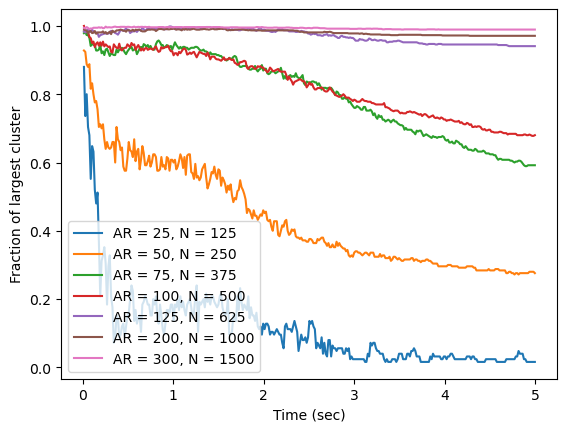

In [ ]:
# %%

fig,ax=plt.subplots()

for pth in pathlist:
    
    # find csv file
    data_path = None
    for file in Path(pth).rglob('*.csv'):
        if str(file.stem).endswith('lastFrame'):
            continue        
        data_path = file
        break
    
    log_string = ''
    
    file_id,surfix,num_rods,AR,datetime_string = parse_path_string(data_path)
    time_line, node_list, contact_list = import_all_log(data_path,max_rows=100000)
    
    time_line = np.array(time_line)
    time_line = time_line[time_line <= 10]
    node_list = node_list[:len(time_line)]
    contact_list = contact_list[:len(time_line)]
    
    print(f'Size of time_line: {len(time_line)}')
    print(f'Number of rods: {num_rods}')
    
    log_string = log_string + f'Number of rods: {num_rods}\n'
    log_string = log_string + f'Number of time points: {len(time_line)}\n'
    
    output_path = f'{output_root}/{protocol_id}/{file_id}_{surfix}'
    if not os.path.exists(output_path):
        os.makedirs(output_path)
        start_point = 0
    else:
        start_point = len(glob.glob(f'{output_path}/*.png'))        
    start_point = 0
    nodes_in_matrix = node_list[0].reshape((-1,30))
    packing_center = np.mean(np.mean(nodes_in_matrix.reshape((-1,10,3)),axis=1),axis=0)
    
    # locked_nodes = []
    # for rr in nodes_in_matrix.reshape((-1,10,3)):
    #     I = np.linalg.norm(rr - packing_center,axis=1) < 0.1
    #     locked_nodes.append(rr[I,:])
    
    cluster_size = np.zeros((len(node_list)-1),dtype=int)
    
    for i in range(1,len(node_list),1):
        nodes_in_matrix = node_list[i].reshape((-1,30))
        
        curr_contact_list = contact_list[i]
        curr_contact_list = curr_contact_list.reshape(-1,18)
        
        graph = nx.Graph()
        graph.add_nodes_from(range(num_rods))
        graph.add_edges_from(curr_contact_list[:,4:6])
        conn_comp = list(nx.connected_components(graph))        
        cl_size = [len(cc) for cc in conn_comp]        
        cluster_size[i-1] = max(cl_size)
        
    ax.plot(time_line[1:],cluster_size/num_rods,label=f'AR = {AR}, N = {num_rods}')

plt.legend()
plt.xlabel('Time (sec)')
plt.ylabel('Fraction of largest cluster')
    

# at edges between (idx1, idx3) and (idx2, idx4)
# (4 * idx1 + e1, contact_gradient[e1], idx5);
# (4 * idx3 + e1, contact_gradient[e1 + 3], idx5);
# (4 * idx2 + e1, contact_gradient[e1 + 6], idx6);
# (4 * idx4 + e1, contact_gradient[e1 + 9], idx6);